In [132]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# Test labels
import pandas as pd
import geopandas as gpd

labels = pd.read_csv("/mnt/sherlock/oak/embed_develop/dhs_data/labels/dhs_labels.csv")

# Transform labels to GeoDataFrame
labels = gpd.GeoDataFrame(
    labels, geometry=gpd.points_from_xy(x=labels.lon, y=labels.lat), crs="EPSG:4326"
).to_crs("EPSG:3857")

# Buffer labels to create a 5000m radius around each point
labels["geometry"] = labels.geometry.buffer(5000, cap_style=3)

# Take back to degrees for plotting
labels = labels.to_crs("EPSG:4326")

In [68]:
labels

,DHSID_EA,year,lat,lon,pca_comp,urban,datetime,geometry
0,KE-2020-8#-00000002,2020,-4.200655,39.356982,-2.367933,R,2020-01-01,"POLYGON ((39.4019 -4.15586, 39.4019 -4.24545, ..."
1,KE-2020-8#-00000005,2020,-4.027349,39.539536,-1.862679,R,2020-01-01,"POLYGON ((39.58445 -3.98254, 39.58445 -4.07215..."
2,KE-2020-8#-00000012,2020,-4.510408,39.165574,-2.018392,R,2020-01-01,"POLYGON ((39.21049 -4.46563, 39.21049 -4.55518..."
3,KE-2020-8#-00000015,2020,-4.492379,39.431670,-1.295686,R,2020-01-01,"POLYGON ((39.47659 -4.4476, 39.47659 -4.53716,..."
4,KE-2020-8#-00000028,2020,-3.183536,40.049758,-0.569875,R,2020-01-01,"POLYGON ((40.09467 -3.13869, 40.09467 -3.22838..."
...,...,...,...,...,...,...,...,...
1971,KE-2022-8Z-00001686,2022,-1.267674,36.824082,4.843354,U,2022-01-01,"POLYGON ((36.869 -1.22277, 36.869 -1.31258, 36..."
1972,KE-2022-8Z-00001687,2022,-1.302119,36.842689,1.497795,U,2022-01-01,"POLYGON ((36.8876 -1.25721, 36.8876 -1.34702, ..."
1973,KE-2022-8Z-00001688,2022,-1.315060,36.843141,5.608796,U,2022-01-01,"POLYGON ((36.88806 -1.27016, 36.88806 -1.35996..."
1974,KE-2022-8Z-00001691,2022,-1.234332,36.750135,5.459935,U,2022-01-01,"POLYGON ((36.79505 -1.18943, 36.79505 -1.27924..."


In [2]:
from planet_download.client import BasemapsClient

In [ ]:
client = BasemapsClient()


In [7]:
mosaics = list(client.list_mosaics())

In [ ]:
mosaics[1]._region_search()

{'bbox': [-179, -56, 180, 68],
 'coordinate_system': 'EPSG:3857',
 'datatype': 'byte',
 'first_acquired': '2016-02-01T00:00:00.000Z',
 'grid': {'quad_size': 2048, 'resolution': 4.777314267823516},
 'id': 'a97687cf-65db-4f34-ab2c-2ef7596a24ce',
 'interval': '1 mon',
 'item_types': ['PSScene', 'REOrthoTile'],
 'last_acquired': '2016-03-01T00:00:00.000Z',
 'level': 15,
 'name': 'global_monthly_2016_02_mosaic',
 'product_type': 'timelapse',
 'quad_download': True}

In [73]:
labels.iloc[0].geometry.bounds

(39.31206623579403, -4.245448813629545, 39.40189776420598, -4.155858614128308)

In [75]:
list(mosaics[0]._bbox_search(labels.iloc[0].geometry.bounds))

[{'_links': {'_self': 'https://api.planet.com/basemaps/v1/mosaics/48fff803-4104-49bc-b913-7467b7a5ffb5/quads/2495-2000?api_key=PLAK5ec438d8de474086a209560607f5441f',
   'download': 'https://link.planet.com/basemaps/v1/mosaics/48fff803-4104-49bc-b913-7467b7a5ffb5/quads/2495-2000/full?api_key=PLAK5ec438d8de474086a209560607f5441f',
   'items': 'https://api.planet.com/basemaps/v1/mosaics/48fff803-4104-49bc-b913-7467b7a5ffb5/quads/2495-2000/items?api_key=PLAK5ec438d8de474086a209560607f5441f',
   'thumbnail': 'https://tiles.planet.com/basemaps/v1/planet-tiles/global_monthly_2016_01_mosaic/gmap/12/2495/2095.png?api_key=PLAK5ec438d8de474086a209560607f5441f'},
  'bbox': [39.2871093696, -4.21494314075, 39.3749999946, -4.12728532262],
  'id': '2495-2000',
  'percent_covered': 100},
 {'_links': {'_self': 'https://api.planet.com/basemaps/v1/mosaics/48fff803-4104-49bc-b913-7467b7a5ffb5/quads/2496-2000?api_key=PLAK5ec438d8de474086a209560607f5441f',
   'download': 'https://link.planet.com/basemaps/v1/

## Play around with series

In [ ]:
kenya = gpd.read_file("kenya.geojson")
bounds_kenya = kenya.total_bounds

series = client.series(name="Global Quarterly")
mosaics = list(series.mosaics("2020-01-01", "2020-12-31"))

quads = []
for mosaic in mosaics:
    for quad in mosaic.quads(bbox=bounds_kenya):
        if quad.downloadable:
            quads.append(quad)

In [171]:
dict(quads[0])

{'client': <planet_download.client.BasemapsClient at 0x7627b00b5f40>,
 'info': {'bbox': [33.7499999954, 5.26600788213, 33.9257812453, 5.44102230302],
  'id': '1216-1054',
  'percent_covered': 100},
 'links': {'_self': 'https://api.planet.com/basemaps/v1/mosaics/b4848ebc-2d46-4870-a244-3346a7b0b20a/quads/1216-1054?api_key=PLAK5ec438d8de474086a209560607f5441f',
  'download': 'https://link.planet.com/basemaps/v1/mosaics/b4848ebc-2d46-4870-a244-3346a7b0b20a/quads/1216-1054/full?api_key=PLAK5ec438d8de474086a209560607f5441f',
  'items': 'https://api.planet.com/basemaps/v1/mosaics/b4848ebc-2d46-4870-a244-3346a7b0b20a/quads/1216-1054/items?api_key=PLAK5ec438d8de474086a209560607f5441f',
  'thumbnail': 'https://tiles.planet.com/basemaps/v1/planet-tiles/global_quarterly_2020q1_mosaic/gmap/11/1216/993.png?api_key=PLAK5ec438d8de474086a209560607f5441f'},
 'id': '1216-1054',
 'coverage': 100,
 'bounds': [33.7499999954, 5.26600788213, 33.9257812453, 5.44102230302],
 'mosaic': <planet_download.client.M

In [ ]:
from shapely.geometry import box

# Transform to a geopandas DataFrame
cols = [
    "id",
    "coverage",
    "bounds",
    "mosaic_name",
    "x",
    "y",
    "level",
]
df = pd.DataFrame([dict(d) for d in quads], columns=cols)
df["geometry"] = df.bounds.apply(lambda x: box(*x))
df = gpd.GeoDataFrame(df, geometry="geometry", crs="EPSG:4326")
df.shape


(7842, 8)

<Axes: >

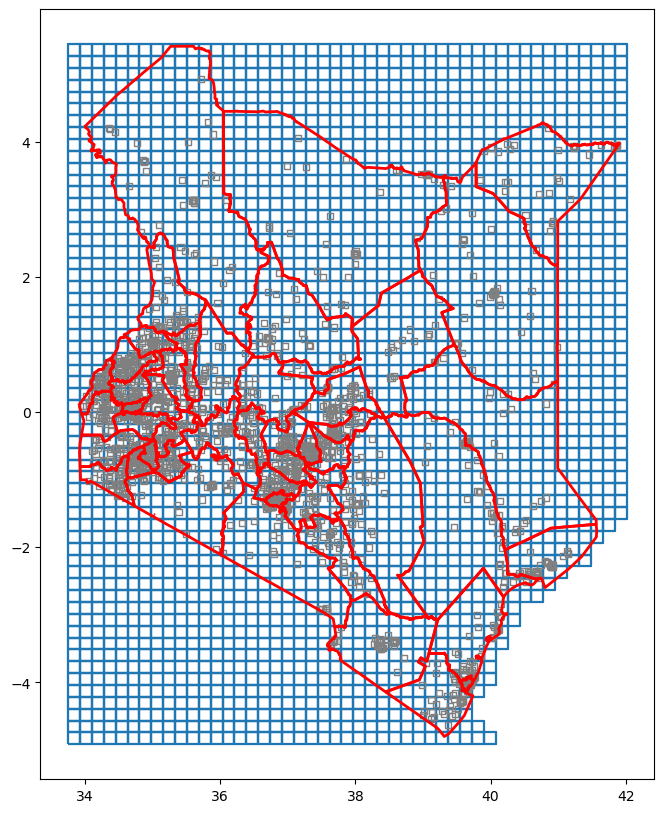

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 10))
df.boundary.plot(ax=ax)
labels.boundary.plot(ax=ax, color="gray", linewidth=1)
kenya.boundary.plot(ax=ax, color="red", linewidth=2)

In [ ]:
overlap = gpd.sjoin(
    df, labels[labels.year == 2020], how="inner", predicate="intersects"
)
overlap

,id,coverage,bounds,mosaic_name,x,y,level,geometry,index_right,DHSID_EA,year,lat,lon,pca_comp,urban,datetime
381,1221-1046,100,"[34.6289062452, 3.86425461524, 34.8046874952, ...",global_quarterly_2020q1_mosaic,1221,1046,15,"POLYGON ((34.80469 3.86425, 34.80469 4.03962, ...",21,KE-2020-8#-00000354,2020,3.979246,34.763349,-3.889326,R,2020-01-01
382,1222-1046,100,"[34.8046874952, 3.86425461524, 34.9804687452, ...",global_quarterly_2020q1_mosaic,1222,1046,15,"POLYGON ((34.98047 3.86425, 34.98047 4.03962, ...",21,KE-2020-8#-00000354,2020,3.979246,34.763349,-3.889326,R,2020-01-01
421,1261-1046,100,"[41.6601562443, 3.86425461524, 41.8359374942, ...",global_quarterly_2020q1_mosaic,1261,1046,15,"POLYGON ((41.83594 3.86425, 41.83594 4.03962, ...",222,KE-2020-8#-00004905,2020,3.945827,41.865475,-1.154755,U,2020-01-01
422,1262-1046,100,"[41.8359374942, 3.86425461524, 42.0117187442, ...",global_quarterly_2020q1_mosaic,1262,1046,15,"POLYGON ((42.01172 3.86425, 42.01172 4.03962, ...",222,KE-2020-8#-00004905,2020,3.945827,41.865475,-1.154755,U,2020-01-01
429,1222-1045,100,"[34.8046874952, 3.68885514269, 34.9804687452, ...",global_quarterly_2020q1_mosaic,1222,1045,15,"POLYGON ((34.98047 3.68886, 34.98047 3.86425, ...",164,KE-2020-8#-00003636,2020,3.721403,34.853267,1.726858,U,2020-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7736,1249-999,100,"[39.5507812446, -4.3902289258, 39.7265624945, ...",global_quarterly_2020q3_mosaic,1249,999,15,"POLYGON ((39.72656 -4.39023, 39.72656 -4.21494...",218,KE-2020-8#-00004847,2020,-4.287741,39.567214,1.372884,U,2020-01-01
7736,1249-999,100,"[39.5507812446, -4.3902289258, 39.7265624945, ...",global_quarterly_2020q3_mosaic,1249,999,15,"POLYGON ((39.72656 -4.39023, 39.72656 -4.21494...",37,KE-2020-8#-00000793,2020,-4.270849,39.588812,-0.354953,U,2020-01-01
7767,1246-998,100,"[39.0234374946, -4.56547355002, 39.1992187446,...",global_quarterly_2020q3_mosaic,1246,998,15,"POLYGON ((39.19922 -4.56547, 39.19922 -4.39023...",2,KE-2020-8#-00000012,2020,-4.510408,39.165574,-2.018392,R,2020-01-01
7768,1247-998,100,"[39.1992187446, -4.56547355002, 39.3749999946,...",global_quarterly_2020q3_mosaic,1247,998,15,"POLYGON ((39.375 -4.56547, 39.375 -4.39023, 39...",2,KE-2020-8#-00000012,2020,-4.510408,39.165574,-2.018392,R,2020-01-01


In [ ]:
overlap.groupby(["DHSID_EA"])[["id", "mosaic_name"]].apply(
    lambda x: x.values.tolist()
).to_dict()

{'KE-2020-8#-00000002': [['1247-1000', 'global_quarterly_2020q1_mosaic'],
  ['1248-1000', 'global_quarterly_2020q1_mosaic'],
  ['1247-999', 'global_quarterly_2020q1_mosaic'],
  ['1248-999', 'global_quarterly_2020q1_mosaic'],
  ['1247-1000', 'global_quarterly_2020q2_mosaic'],
  ['1248-1000', 'global_quarterly_2020q2_mosaic'],
  ['1247-999', 'global_quarterly_2020q2_mosaic'],
  ['1248-999', 'global_quarterly_2020q2_mosaic'],
  ['1247-1000', 'global_quarterly_2020q3_mosaic'],
  ['1248-1000', 'global_quarterly_2020q3_mosaic'],
  ['1247-999', 'global_quarterly_2020q3_mosaic'],
  ['1248-999', 'global_quarterly_2020q3_mosaic']],
 'KE-2020-8#-00000005': [['1248-1001', 'global_quarterly_2020q1_mosaic'],
  ['1249-1001', 'global_quarterly_2020q1_mosaic'],
  ['1248-1000', 'global_quarterly_2020q1_mosaic'],
  ['1249-1000', 'global_quarterly_2020q1_mosaic'],
  ['1248-1001', 'global_quarterly_2020q2_mosaic'],
  ['1249-1001', 'global_quarterly_2020q2_mosaic'],
  ['1248-1000', 'global_quarterly_2020q2_

In [203]:
idx = overlap.drop_duplicates(subset=["id", "mosaic_name"]).index.tolist()
sel_quads = [quads[i] for i in idx]

In [239]:
overlap

,id,coverage,bounds,mosaic_name,x,y,level,geometry,index_right,DHSID_EA,year,lat,lon,pca_comp,urban,datetime
381,1221-1046,100,"[34.6289062452, 3.86425461524, 34.8046874952, ...",global_quarterly_2020q1_mosaic,1221,1046,15,"POLYGON ((34.80469 3.86425, 34.80469 4.03962, ...",21,KE-2020-8#-00000354,2020,3.979246,34.763349,-3.889326,R,2020-01-01
382,1222-1046,100,"[34.8046874952, 3.86425461524, 34.9804687452, ...",global_quarterly_2020q1_mosaic,1222,1046,15,"POLYGON ((34.98047 3.86425, 34.98047 4.03962, ...",21,KE-2020-8#-00000354,2020,3.979246,34.763349,-3.889326,R,2020-01-01
421,1261-1046,100,"[41.6601562443, 3.86425461524, 41.8359374942, ...",global_quarterly_2020q1_mosaic,1261,1046,15,"POLYGON ((41.83594 3.86425, 41.83594 4.03962, ...",222,KE-2020-8#-00004905,2020,3.945827,41.865475,-1.154755,U,2020-01-01
422,1262-1046,100,"[41.8359374942, 3.86425461524, 42.0117187442, ...",global_quarterly_2020q1_mosaic,1262,1046,15,"POLYGON ((42.01172 3.86425, 42.01172 4.03962, ...",222,KE-2020-8#-00004905,2020,3.945827,41.865475,-1.154755,U,2020-01-01
429,1222-1045,100,"[34.8046874952, 3.68885514269, 34.9804687452, ...",global_quarterly_2020q1_mosaic,1222,1045,15,"POLYGON ((34.98047 3.68886, 34.98047 3.86425, ...",164,KE-2020-8#-00003636,2020,3.721403,34.853267,1.726858,U,2020-01-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7736,1249-999,100,"[39.5507812446, -4.3902289258, 39.7265624945, ...",global_quarterly_2020q3_mosaic,1249,999,15,"POLYGON ((39.72656 -4.39023, 39.72656 -4.21494...",218,KE-2020-8#-00004847,2020,-4.287741,39.567214,1.372884,U,2020-01-01
7736,1249-999,100,"[39.5507812446, -4.3902289258, 39.7265624945, ...",global_quarterly_2020q3_mosaic,1249,999,15,"POLYGON ((39.72656 -4.39023, 39.72656 -4.21494...",37,KE-2020-8#-00000793,2020,-4.270849,39.588812,-0.354953,U,2020-01-01
7767,1246-998,100,"[39.0234374946, -4.56547355002, 39.1992187446,...",global_quarterly_2020q3_mosaic,1246,998,15,"POLYGON ((39.19922 -4.56547, 39.19922 -4.39023...",2,KE-2020-8#-00000012,2020,-4.510408,39.165574,-2.018392,R,2020-01-01
7768,1247-998,100,"[39.1992187446, -4.56547355002, 39.3749999946,...",global_quarterly_2020q3_mosaic,1247,998,15,"POLYGON ((39.375 -4.56547, 39.375 -4.39023, 39...",2,KE-2020-8#-00000012,2020,-4.510408,39.165574,-2.018392,R,2020-01-01


In [240]:
downloads = series.download_selection(
    sel_quads[:100],
    flat=False,
    save_dir="./planet_downloads_test",
    filename_template="{x}_{y}.tif",
    nthreads=10,
)

In [241]:
list(downloads)

['./planet_downloads_test/global_quarterly_2020q1_mosaic/1221_1046.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1222_1046.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1261_1046.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1262_1046.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1222_1045.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1259_1045.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1260_1045.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1222_1044.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1246_1044.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1227_1043.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1246_1043.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1252_1043.tif',
 './planet_downloads_test/global_quarterly_2020q1_mosaic/1253_1043.tif',
 './planet_downloads_test/global_quarterly_2020q1_m